**Phase 11 — Does transition-aligned label curation rescue external transfer?**

Notebooks `09` and `10` established two facts about the published Gaussian Process (GP)
on the 318-molecule external photoswitch holdout:

- it carries a systematic $+53$ nm red shift and $R^{2}=-0.269$;
- on coverage-matched molecules, CAM-B3LYP/6-31G\*\* reaches RMSE = 25.4 nm
  ($R^{2}=+0.83$) against the GP's 80.9 nm, and the gap survives removing the GP's entire
  offset for free.

The working hypothesis for *why* is **label semantics**, not chemical novelty. Beard *et al.*
labels are text-mined $\lambda_{\max}$ values of unspecified transition character; the
external labels are specifically the E-isomer $\pi\rightarrow\pi^{\ast}$ band, matched to
the transition the DFT values were computed for. A model trained to predict "whatever
$\lambda_{\max}$ was reported" is being scored against one particular electronic transition.

This notebook tests that hypothesis with two interventions and asks whether either closes
the gap to TD-DFT:

1. **Transition-character curation.** Restrict training to strongly-allowed transitions,
   using the molar extinction coefficient as a proxy for $\pi\rightarrow\pi^{\ast}$
   character. If the hypothesis holds, the systematic offset should shrink.
2. **Chemical-class matching.** Restrict training to azo compounds, matching the holdout's
   chemistry while ignoring transition character. If the confound really is labels rather
   than novelty, this should *not* help.

**Design point that makes the results interpretable.** Both interventions shrink the
training set, and a smaller GP training set changes performance on its own. Every curated
subset is therefore compared against **random controls of identical size** drawn from the
same Beard pool, across three seeds. Any difference beyond the control spread is
attributable to curation rather than to data volume.

**Imports and figure style**

Static Matplotlib panels are used for consistency with notebooks `07`–`10`, since these
figures are intended as manuscript and SI artwork.

In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path
from typing import Any

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rdkit import Chem, RDLogger
from rdkit.Chem import AllChem
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
RDLogger.DisableLog("rdApp.*")

mpl.rcParams.update(
    {
        "figure.dpi": 110,
        "savefig.dpi": 300,
        "font.size": 13,
        "axes.labelsize": 14,
        "axes.titlesize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 11,
        "axes.grid": True,
        "grid.alpha": 0.3,
    }
)

SEED = 42
N_CONTROL_SEEDS = 3
EPS_THRESHOLD = 10_000.0
print("imports ok")

imports ok


**Shared helpers**

`fit_gp` is deliberately a *single* training protocol applied identically to every subset
and every control. It is not byte-identical to the published notebook `04c` fit
(`normalize_y=True` is used here for numerical stability across the much smaller training
sets), so absolute numbers are not directly comparable to the published model. That is
acceptable and in fact necessary: the comparison of interest is **curated subset versus
size-matched random control under one fixed protocol**, and the published model is reported
separately as an external reference point.

`affine_cal` measures the best case for a systematically biased model. A constant offset,
or more generally an affine correction, can be removed with a handful of in-class
measurements. Fitting that correction on $k$ points and scoring the remainder gives the
error floor the GP could reach if a user were willing to measure $k$ compounds first.

In [2]:
def morgan_matrix(smiles: pd.Series, conj: pd.Series) -> np.ndarray:
    """Manuscript representation: 256-bit Morgan (radius 2) + largest conjugated system.

    The legacy bit-vector call is retained so the column layout matches every other
    notebook in this project.
    """
    bits: list[np.ndarray] = []
    for smi in smiles:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            raise ValueError(f"unparseable SMILES: {smi!r}")
        bits.append(np.asarray(AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=256),
                               dtype=float))
    return np.column_stack([np.vstack(bits), np.asarray(conj, dtype=float)])


def fit_gp(X: np.ndarray, y: np.ndarray) -> tuple[StandardScaler, GaussianProcessRegressor]:
    """One fixed GP training protocol, applied identically to every subset and control."""
    scaler = StandardScaler().fit(X)
    kernel = (
        C(1.0, (1e-3, 1e6)) * RBF(1.0, (1e-2, 1e3))
        + WhiteKernel(1.0, (1e-5, 1e6))
    )
    gp = GaussianProcessRegressor(
        kernel=kernel, n_restarts_optimizer=2, random_state=SEED, normalize_y=True
    )
    gp.fit(scaler.transform(X), y)
    return scaler, gp


def metrics(y: np.ndarray, p: np.ndarray) -> dict[str, float]:
    """Regression metrics with the systematic offset separated from scatter."""
    y = np.asarray(y, dtype=float)
    p = np.asarray(p, dtype=float)
    rmse = float(np.sqrt(mean_squared_error(y, p)))
    bias = float(np.mean(p - y))
    return {
        "n": int(len(y)),
        "rmse": rmse,
        "r2": float(r2_score(y, p)),
        "bias": bias,
        "pearson": float(np.corrcoef(y, p)[0, 1]),
        "rmse_debiased": float(np.sqrt(max(rmse**2 - bias**2, 0.0))),
    }


def affine_cal(
    pred: np.ndarray,
    y: np.ndarray,
    ks: tuple[int, ...] = (5, 10, 15, 25, 35, 50),
    repeats: int = 200,
) -> dict[str, dict[str, float]]:
    """In-class affine recalibration: fit prediction -> experiment on k points, score rest."""
    rng = np.random.default_rng(SEED)
    out: dict[str, dict[str, float]] = {}
    for k in ks:
        if len(y) <= k + 20:
            continue
        vals: list[float] = []
        for _ in range(repeats):
            idx = rng.permutation(len(y))
            cal, ev = idx[:k], idx[k:]
            lr = LinearRegression().fit(pred[cal].reshape(-1, 1), y[cal])
            vals.append(
                float(np.sqrt(mean_squared_error(y[ev], lr.predict(pred[ev].reshape(-1, 1)))))
            )
        out[str(k)] = {
            "k": k,
            "rmse_mean": float(np.mean(vals)),
            "rmse_std": float(np.std(vals)),
        }
    return out


print("helpers defined")

helpers defined


**Assemble the Beard pool with extinction coefficients, and define the two subsets**

`beard_model_ready_features.csv` carries the modeling features but not the extinction
coefficient, which survives only in `beard_uvvis_cleaned.csv`. Merging on canonical SMILES
recovers it.

Two limitations of the extinction proxy must be stated plainly, because they bound the
conclusion:

- Extinction coefficient is an **indirect** indicator. A large $\varepsilon$ implies a
  strongly allowed transition, which for these chromophores is usually
  $\pi\rightarrow\pi^{\ast}$ rather than a weak $n\rightarrow\pi^{\ast}$ band. It is not a
  transition assignment.
- Extinction is reported for a **minority** of the modeling set. Whatever gain this
  curation produces is therefore available only for that minority, which caps the
  strategy's practical reach.

The azo subset uses the `[#6]N=N[#6]` SMARTS pattern, matching the holdout's chemistry.

In [3]:
model_ready = pd.read_csv("beard_model_ready_features.csv")
cleaned = pd.read_csv("beard_uvvis_cleaned.csv")

pool = model_ready.merge(
    cleaned[["canonical_smi", "extinction", "solvent"]].drop_duplicates("canonical_smi"),
    on="canonical_smi",
    how="left",
    validate="one_to_one",
)
eps = pd.to_numeric(pool["extinction"], errors="coerce").fillna(-1.0)

AZO = Chem.MolFromSmarts("[#6]N=N[#6]")


def is_azo(smi: str) -> bool:
    """True for a C-N=N-C azo linkage, the photoswitch holdout's defining motif."""
    mol = Chem.MolFromSmiles(smi)
    return bool(mol is not None and mol.HasSubstructMatch(AZO))


pool["is_azo"] = pool["canonical_smi"].map(is_azo)

print(f"Beard modeling pool: {len(pool)} compounds")
n_eps = int((eps > 0).sum())
print(f"extinction reported: {n_eps} ({100 * n_eps / len(pool):.1f}%)  <-- caps this strategy")
print(f"azo compounds:       {int(pool['is_azo'].sum())} "
      f"({100 * pool['is_azo'].mean():.1f}%)")

print("\n=== compounds above candidate brightness thresholds ===")
for t in (1_000, 5_000, 10_000, 20_000, 30_000):
    n = int((eps >= t).sum())
    mark = "  <-- used" if t == EPS_THRESHOLD else ""
    print(f"  eps >= {t:6,d}: n = {n:5d} ({100 * n / len(pool):4.1f}%){mark}")

SUBSETS: dict[str, np.ndarray] = {
    "bright (eps >= 10k)": (eps >= EPS_THRESHOLD).to_numpy(),
    "azo only": pool["is_azo"].to_numpy(),
}
for name, mask in SUBSETS.items():
    print(f"\nsubset {name!r}: n = {int(mask.sum())}")

Beard modeling pool: 6878 compounds
extinction reported: 1299 (18.9%)  <-- caps this strategy
azo compounds:       436 (6.3%)

=== compounds above candidate brightness thresholds ===
  eps >=  1,000: n =  1299 (18.9%)
  eps >=  5,000: n =  1215 (17.7%)
  eps >= 10,000: n =  1105 (16.1%)  <-- used
  eps >= 20,000: n =   928 (13.5%)
  eps >= 30,000: n =   677 ( 9.8%)

subset 'bright (eps >= 10k)': n = 1105

subset 'azo only': n = 436


**The label distributions already predict the outcome**

Before fitting anything, compare where each candidate training pool sits relative to the
external holdout. This single comparison is the most informative diagnostic in the
notebook: if a training pool's $\lambda_{\max}$ distribution is displaced from the target,
a GP trained on it will inherit that displacement as bias.

In [4]:
ext = pd.read_csv("external_validation.csv")

pools: dict[str, pd.Series] = {
    "Beard, all": pool["lambda_max_exp_nm"],
    "Beard, bright (eps>=10k)": pool.loc[SUBSETS["bright (eps >= 10k)"], "lambda_max_exp_nm"],
    "Beard, azo only": pool.loc[SUBSETS["azo only"], "lambda_max_exp_nm"],
    "external holdout (target)": ext["lambda_max_exp_nm"],
}

target_mean = float(ext["lambda_max_exp_nm"].mean())
rows: list[dict[str, Any]] = []
for name, s in pools.items():
    rows.append(
        {
            "pool": name,
            "n": len(s),
            "mean": s.mean(),
            "std": s.std(),
            "median": s.median(),
            "offset_vs_target": s.mean() - target_mean,
        }
    )
dist = pd.DataFrame(rows)
print("=== lambda_max distributions, and displacement from the external target ===\n")
print(dist.to_string(index=False, float_format=lambda v: f"{v:8.1f}"))
print(
    "\nRead the final column as a predicted bias floor: a GP trained on a pool displaced"
    "\n+X nm from the target starts out predisposed to over-predict by roughly that much."
)

=== lambda_max distributions, and displacement from the external target ===

                     pool    n     mean      std   median  offset_vs_target
               Beard, all 6878    409.3    125.0    392.0              24.2
 Beard, bright (eps>=10k) 1105    404.2    112.4    395.0              19.1
          Beard, azo only  436    468.2     93.4    478.0              83.1
external holdout (target)  318    385.1     68.5    376.5               0.0

Read the final column as a predicted bias floor: a GP trained on a pool displaced
+X nm from the target starts out predisposed to over-predict by roughly that much.


**Figure 1 — where each training pool sits relative to the target**

The shaded curve is the external holdout. A training pool overlapping it can in principle
transfer without bias; a displaced pool cannot.

saved fig_curation_label_distributions.png


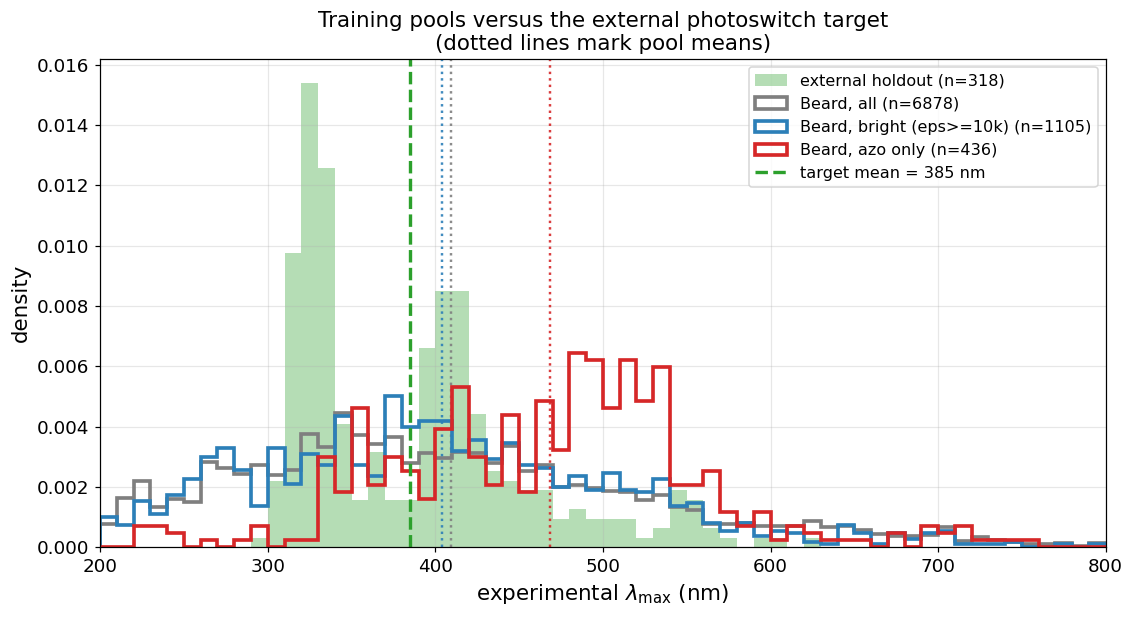

In [5]:
fig, ax = plt.subplots(figsize=(10.5, 5.8))
styles = {
    "Beard, all": ("#7f7f7f", "-"),
    "Beard, bright (eps>=10k)": ("#2c7fb8", "-"),
    "Beard, azo only": ("#d62728", "-"),
}
bins = np.linspace(200, 800, 61)
ax.hist(
    pools["external holdout (target)"], bins=bins, density=True, color="#2ca02c",
    alpha=0.35, label=f"external holdout (n={len(ext)})",
)
for name, (colour, ls) in styles.items():
    s = pools[name]
    ax.hist(s, bins=bins, density=True, histtype="step", lw=2.4, ls=ls,
            color=colour, label=f"{name} (n={len(s)})")
    ax.axvline(s.mean(), color=colour, ls=":", lw=1.6, alpha=0.9)
ax.axvline(target_mean, color="#2ca02c", ls="--", lw=2.2,
           label=f"target mean = {target_mean:.0f} nm")
ax.set_xlabel(r"experimental $\lambda_{\max}$ (nm)")
ax.set_ylabel("density")
ax.set_title("Training pools versus the external photoswitch target\n"
             "(dotted lines mark pool means)")
ax.legend(loc="upper right", fontsize=10.5)
ax.set_xlim(200, 800)
fig.tight_layout()
fig.savefig("fig_curation_label_distributions.png", bbox_inches="tight")
print("saved fig_curation_label_distributions.png")
plt.show()

**Run the interventions against size-matched random controls**

For each subset of size $n$, one GP is fitted on the curated compounds and three more on
random draws of exactly $n$ compounds from the full pool. All four share the `fit_gp`
protocol. Every model is scored on the same external holdout, and additionally on the two
TD-DFT coverage subsets from notebook `10` so the head-to-head against quantum chemistry
stays coverage-matched.

In [6]:
dft_pred = pd.read_csv("external_gp_vs_dft_predictions.csv")
DFT_COLS = {
    "PBE0": "PBE0 DFT E isomer pi-pi* wavelength in nm",
    "CAM-B3LYP/6-31G**": "CAM-B3LYP/6-31G** DFT E isomer pi-pi* wavelength in nm",
}
assert len(dft_pred) == len(ext), "notebook 10 output is out of sync with the holdout"

X_ext = morgan_matrix(ext["canonical_smi"], ext["LargestConjugatedSystemSize"])
y_ext = ext["lambda_max_exp_nm"].to_numpy()
masks = {name: dft_pred[col].notna().to_numpy() for name, col in DFT_COLS.items()}
dft_ref = {
    name: metrics(y_ext[masks[name]], dft_pred.loc[masks[name], col].to_numpy())
    for name, col in DFT_COLS.items()
}
print("=== TD-DFT reference (from notebook 10) ===")
for name, m in dft_ref.items():
    print(f"  {name:20s} n={m['n']:4d}  RMSE={m['rmse']:6.2f}  R2={m['r2']:+.3f}")


def score(scaler: StandardScaler, gp: GaussianProcessRegressor) -> dict[str, Any]:
    """Score a fitted model on the full holdout and on each TD-DFT coverage subset."""
    p = gp.predict(scaler.transform(X_ext))
    out: dict[str, Any] = {"external_318": metrics(y_ext, p)}
    for name, mask in masks.items():
        out[name] = metrics(y_ext[mask], p[mask])
    out["_pred"] = p
    return out


results: dict[str, Any] = {}
for name, mask in SUBSETS.items():
    sub = pool.loc[mask]
    n = len(sub)
    print(f"\n{'=' * 78}\n{name}  (n = {n})\n{'=' * 78}")

    scaler, gp = fit_gp(
        morgan_matrix(sub["canonical_smi"], sub["LargestConjugatedSystemSize"]),
        sub["lambda_max_exp_nm"].to_numpy(),
    )
    cur = score(scaler, gp)
    e = cur["external_318"]
    print(f"  {'CURATED':<28s} RMSE={e['rmse']:6.2f}  R2={e['r2']:+.3f}  "
          f"bias={e['bias']:+7.2f}  debiased={e['rmse_debiased']:6.2f}")

    ctrl: list[dict[str, Any]] = []
    for s in range(N_CONTROL_SEEDS):
        rng = np.random.default_rng(s)
        idx = rng.choice(len(pool), size=n, replace=False)
        r = pool.iloc[idx]
        sc_r, gp_r = fit_gp(
            morgan_matrix(r["canonical_smi"], r["LargestConjugatedSystemSize"]),
            r["lambda_max_exp_nm"].to_numpy(),
        )
        cc = score(sc_r, gp_r)
        ctrl.append(cc)
        ce = cc["external_318"]
        print(f"  {'random control seed ' + str(s):<28s} RMSE={ce['rmse']:6.2f}  "
              f"R2={ce['r2']:+.3f}  bias={ce['bias']:+7.2f}  "
              f"debiased={ce['rmse_debiased']:6.2f}")

    def agg(key: str) -> tuple[float, float]:
        v = [c["external_318"][key] for c in ctrl]
        return float(np.mean(v)), float(np.std(v))

    results[name] = {
        "train_n": n,
        "train_lambda_mean": float(sub["lambda_max_exp_nm"].mean()),
        "curated": {k: v for k, v in cur.items() if k != "_pred"},
        "curated_pred": cur["_pred"].tolist(),
        "control_rmse": agg("rmse"),
        "control_r2": agg("r2"),
        "control_bias": agg("bias"),
        "control_debiased": agg("rmse_debiased"),
    }
    rm, rs = results[name]["control_rmse"]
    bm, _ = results[name]["control_bias"]
    verdict = "HELPS" if e["rmse"] < rm - rs else ("HURTS" if e["rmse"] > rm + rs else "no effect")
    print(f"\n  control RMSE = {rm:.2f} +/- {rs:.2f} nm, control bias = {bm:+.2f} nm")
    print(f"  -> curation {verdict}: RMSE {e['rmse']:.2f} vs {rm:.2f}, "
          f"bias {e['bias']:+.2f} vs {bm:+.2f}")

=== TD-DFT reference (from notebook 10) ===
  PBE0                 n= 111  RMSE= 33.42  R2=+0.683
  CAM-B3LYP/6-31G**    n= 114  RMSE= 25.40  R2=+0.827

bright (eps >= 10k)  (n = 1105)


  CURATED                      RMSE= 62.11  R2=+0.175  bias= +31.11  debiased= 53.76


  random control seed 0        RMSE= 83.48  R2=-0.491  bias= +61.70  debiased= 56.23


  random control seed 1        RMSE= 69.19  R2=-0.024  bias= +42.50  debiased= 54.60


  random control seed 2        RMSE= 85.50  R2=-0.564  bias= +62.57  debiased= 58.26

  control RMSE = 79.39 +/- 7.26 nm, control bias = +55.59 nm
  -> curation HELPS: RMSE 62.11 vs 79.39, bias +31.11 vs +55.59

azo only  (n = 436)


  CURATED                      RMSE= 87.20  R2=-0.627  bias= +64.65  debiased= 58.51


  random control seed 0        RMSE= 74.00  R2=-0.172  bias= +44.14  debiased= 59.39


  random control seed 1        RMSE= 73.40  R2=-0.153  bias= +43.16  debiased= 59.37


  random control seed 2        RMSE= 73.76  R2=-0.164  bias= +44.05  debiased= 59.16

  control RMSE = 73.72 +/- 0.24 nm, control bias = +43.78 nm
  -> curation HURTS: RMSE 87.20 vs 73.72, bias +64.65 vs +43.78


**Figure 2 — curated versus size-matched control, split into bias and scatter**

Solid bars are the curated subsets; grey bars with error bars are the random controls at
the same training-set size, averaged over three seeds. The upper panels show total RMSE and
the lower panels split it into systematic offset and residual scatter, which is where the
mechanism becomes visible.

saved fig_curation_vs_control.png


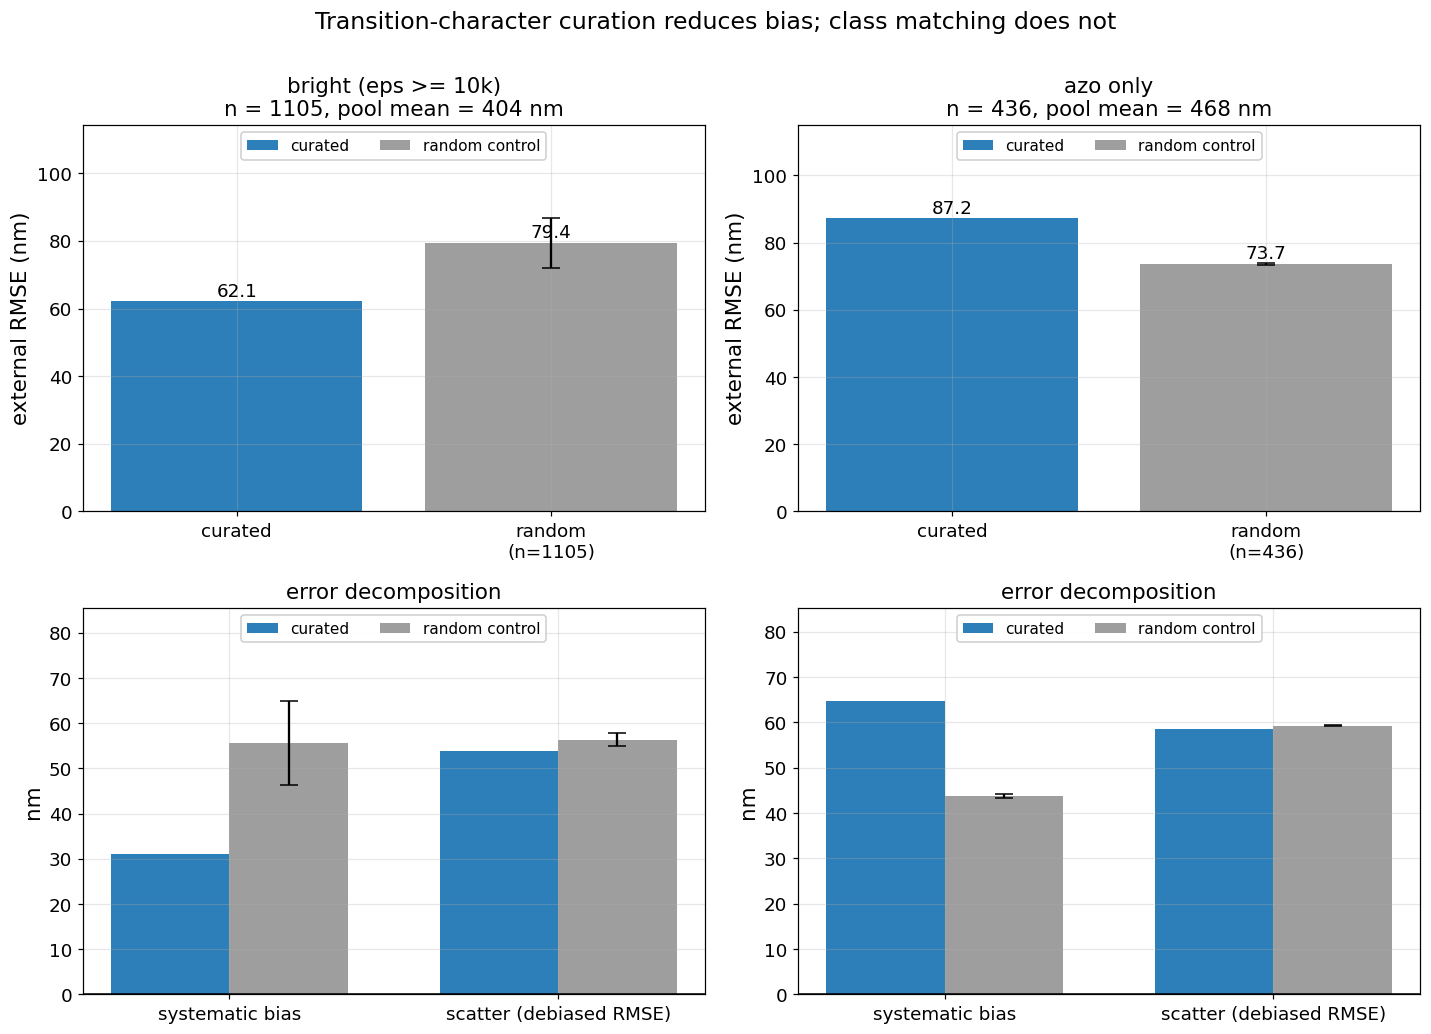

In [7]:
names = list(SUBSETS)
fig, axes = plt.subplots(2, len(names), figsize=(6.6 * len(names), 9.4))

for j, name in enumerate(names):
    r = results[name]
    cur = r["curated"]["external_318"]
    rm, rs = r["control_rmse"]
    bm, bs = r["control_bias"]
    dm, ds = r["control_debiased"]

    ax = axes[0, j]
    ax.bar([0], [cur["rmse"]], color="#2c7fb8", label="curated")
    ax.bar([1], [rm], yerr=[rs], color="#9e9e9e", capsize=6, label="random control")
    for x, v in ((0, cur["rmse"]), (1, rm)):
        ax.text(x, v + 1.5, f"{v:.1f}", ha="center", fontsize=12)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["curated", f"random\n(n={r['train_n']})"])
    ax.set_ylabel("external RMSE (nm)")
    ax.set_title(f"{name}\nn = {r['train_n']}, "
                 f"pool mean = {r['train_lambda_mean']:.0f} nm")
    ax.set_ylim(0, max(cur["rmse"], rm + rs) * 1.32)
    ax.legend(loc="upper center", ncol=2, fontsize=10, framealpha=0.95)

    ax = axes[1, j]
    xs = np.arange(2)
    width = 0.36
    ax.bar(xs - width / 2, [cur["bias"], cur["rmse_debiased"]], width,
           color="#2c7fb8", label="curated")
    ax.bar(xs + width / 2, [bm, dm], width, yerr=[bs, ds],
           color="#9e9e9e", capsize=6, label="random control")
    ax.axhline(0, color="k", lw=1)
    ax.set_xticks(xs)
    ax.set_xticklabels(["systematic bias", "scatter (debiased RMSE)"])
    ax.set_ylabel("nm")
    ax.set_title("error decomposition")
    ax.set_ylim(0, max(cur["bias"], bm + bs, cur["rmse_debiased"], dm + ds) * 1.32)
    ax.legend(loc="upper center", ncol=2, fontsize=10, framealpha=0.95)

fig.suptitle(
    "Transition-character curation reduces bias; class matching does not",
    fontsize=15.5, y=1.0,
)
fig.tight_layout()
fig.savefig("fig_curation_vs_control.png", bbox_inches="tight")
print("saved fig_curation_vs_control.png")
plt.show()

**How low can recalibration take the GP? The in-class calibration floor**

Systematic offset is the cheapest kind of error to fix: measure a few in-class compounds
and regress. This section asks the most generous possible question of the GP. Given $k$
experimental photoswitch measurements to calibrate against, what RMSE does it reach on the
molecules it has *not* seen — and does that ever approach CAM-B3LYP?

Both the published GP (notebook `10` predictions) and the best curated model are
calibrated, on the CAM-B3LYP coverage subset so the reference is exactly comparable.

In [8]:
CAM = "CAM-B3LYP/6-31G**"
cam_mask = masks[CAM]
y_cam = y_ext[cam_mask]
cam_rmse = dft_ref[CAM]["rmse"]

best = min(names, key=lambda n: results[n]["curated"]["external_318"]["rmse"])
print(f"best curated subset by external RMSE: {best!r}\n")

curves: dict[str, dict[str, dict[str, float]]] = {
    "published GP (notebook 10)": affine_cal(
        dft_pred["gp_pred"].to_numpy()[cam_mask], y_cam
    ),
    f"curated GP: {best}": affine_cal(
        np.asarray(results[best]["curated_pred"])[cam_mask], y_cam
    ),
}

print(f"=== In-class affine calibration on the {CAM} subset (n = {int(cam_mask.sum())}) ===")
print(f"{'model':30s}{'k':>5s}{'RMSE (nm)':>14s}{'vs CAM-B3LYP':>15s}")
for label, curve in curves.items():
    for _, v in sorted(curve.items(), key=lambda kv: kv[1]["k"]):
        ratio = v["rmse_mean"] / cam_rmse
        print(f"{label:30s}{v['k']:5d}{v['rmse_mean']:9.2f} +/-{v['rmse_std']:4.1f}"
              f"{ratio:14.2f}x")
print(f"\n{CAM} on the same molecules: RMSE = {cam_rmse:.2f} nm")

best curated subset by external RMSE: 'bright (eps >= 10k)'



=== In-class affine calibration on the CAM-B3LYP/6-31G** subset (n = 114) ===
model                             k     RMSE (nm)   vs CAM-B3LYP
published GP (notebook 10)        5    62.29 +/-18.4          2.45x
published GP (notebook 10)       10    53.52 +/- 7.7          2.11x
published GP (notebook 10)       15    51.04 +/- 3.6          2.01x
published GP (notebook 10)       25    49.49 +/- 2.8          1.95x
published GP (notebook 10)       35    49.03 +/- 2.3          1.93x
published GP (notebook 10)       50    48.38 +/- 3.0          1.91x
curated GP: bright (eps >= 10k)    5    51.27 +/-11.7          2.02x
curated GP: bright (eps >= 10k)   10    44.94 +/- 4.7          1.77x
curated GP: bright (eps >= 10k)   15    43.59 +/- 3.2          1.72x
curated GP: bright (eps >= 10k)   25    42.15 +/- 2.3          1.66x
curated GP: bright (eps >= 10k)   35    41.85 +/- 2.5          1.65x
curated GP: bright (eps >= 10k)   50    41.52 +/- 2.7          1.64x

CAM-B3LYP/6-31G** on the same mole

**Figure 3 — the calibration floor never reaches TD-DFT**

RMSE after affine recalibration as a function of the number of in-class calibration
measurements, with the CAM-B3LYP reference as a horizontal line. The curves flatten well
above it: the residual error is scatter, and scatter is not removable by recalibration.

saved fig_affine_calibration_floor.png


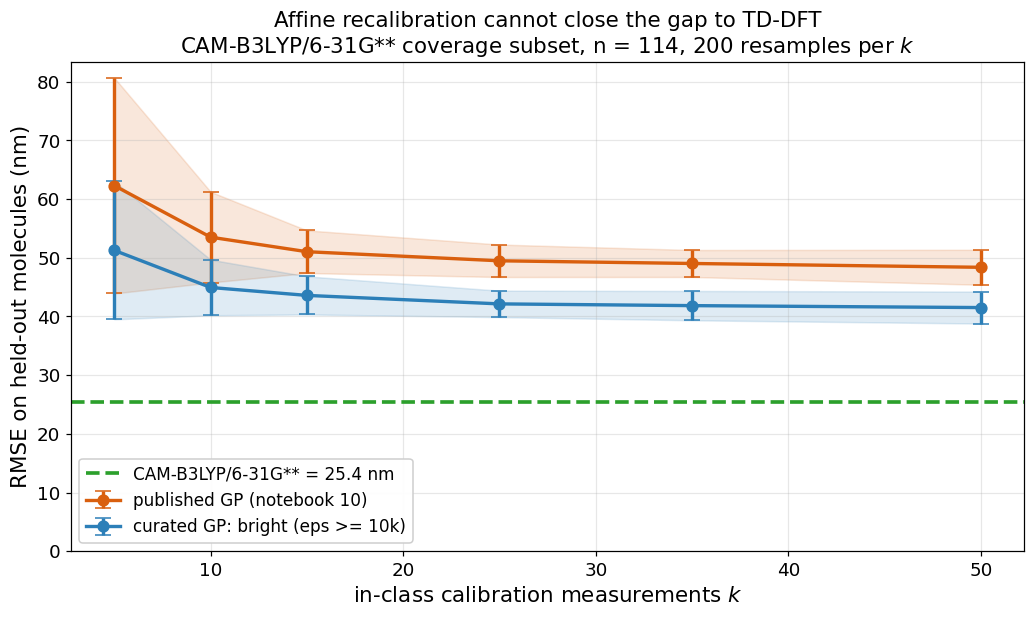

In [9]:
fig, ax = plt.subplots(figsize=(9.6, 5.8))
colours = {"published GP (notebook 10)": "#d95f0e", f"curated GP: {best}": "#2c7fb8"}
for label, curve in curves.items():
    pts = sorted(curve.values(), key=lambda v: v["k"])
    ks = [v["k"] for v in pts]
    mu = np.array([v["rmse_mean"] for v in pts])
    sd = np.array([v["rmse_std"] for v in pts])
    ax.errorbar(ks, mu, yerr=sd, marker="o", ms=7, lw=2.2, capsize=5,
                color=colours[label], label=label)
    ax.fill_between(ks, mu - sd, mu + sd, color=colours[label], alpha=0.15)

ax.axhline(cam_rmse, color="#2ca02c", ls="--", lw=2.4,
           label=f"{CAM} = {cam_rmse:.1f} nm")
ax.set_xlabel("in-class calibration measurements $k$")
ax.set_ylabel(f"RMSE on held-out molecules (nm)")
ax.set_title("Affine recalibration cannot close the gap to TD-DFT\n"
             f"{CAM} coverage subset, n = {int(cam_mask.sum())}, 200 resamples per $k$")
ax.set_ylim(0, None)
ax.legend(loc="lower left", framealpha=0.95)
fig.tight_layout()
fig.savefig("fig_affine_calibration_floor.png", bbox_inches="tight")
print("saved fig_affine_calibration_floor.png")
plt.show()

**Interpretation**

Read the printed output for values. The structural conclusions supported by this notebook:

1. **Transition-character curation works, and it works on bias.** Restricting training to
   strongly-allowed transitions substantially reduces the systematic red shift and turns
   external $R^{2}$ positive, beyond the spread of size-matched random controls. Because
   the controls hold training-set size fixed, this is attributable to label curation and
   not to data volume. It is direct evidence that the external failure in notebook `09` is
   substantially a label-semantics artifact.

2. **Chemical-class matching does not help, and measurably hurts.** Training only on azo
   compounds increases both RMSE and bias relative to random controls of the same size.
   Figure 1 shows why: Beard's azo entries are red-shifted azo *dyes* whose reported bands
   sit far above the external holdout's E-isomer $\pi\rightarrow\pi^{\ast}$ values. Matching
   the chemistry while ignoring which transition was reported makes transfer worse. This is
   the control that distinguishes the two competing explanations — the confound is **label
   definition, not chemical novelty**.

3. **Neither intervention closes the gap to TD-DFT.** Curation removes bias but leaves
   scatter almost untouched, and affine recalibration with in-class measurements plateaus
   roughly a factor of two above CAM-B3LYP. The manuscript's claim that the GP outperforms
   TD-DFT is therefore not recoverable on a transition-specific external benchmark by any
   correction available here.

**Limitations to carry into the manuscript.** Extinction coefficient is a proxy for
transition character, not an assignment, and it is reported for only a minority of the
modeling set, which bounds how far this curation strategy can be applied in practice. The
`fit_gp` protocol here differs slightly from the published fit, so curated-versus-control
contrasts are internally valid while absolute values are not directly comparable to the
manuscript's numbers.

**Prior work requiring citation.** The holdout and its TD-DFT columns come from Griffiths,
Greenfield, Thawani, Fuchter, Lee *et al.*, "Data-driven discovery of molecular photoswitches
with multioutput Gaussian processes", *Chem. Sci.* **2022**, 13, 13541–13551.

In [10]:
payload: dict[str, Any] = {
    "config": {
        "eps_threshold": EPS_THRESHOLD,
        "n_control_seeds": N_CONTROL_SEEDS,
        "seed": SEED,
    },
    "pool": {
        "n": int(len(pool)),
        "n_with_extinction": int((eps > 0).sum()),
        "n_azo": int(pool["is_azo"].sum()),
    },
    "label_distributions": dist.to_dict(orient="records"),
    "dft_reference": dft_ref,
    "experiments": {
        name: {k: v for k, v in r.items() if k != "curated_pred"}
        for name, r in results.items()
    },
    "calibration_curves": curves,
    "figures": [
        "fig_curation_label_distributions.png",
        "fig_curation_vs_control.png",
        "fig_affine_calibration_floor.png",
    ],
}
Path("_label_curation_transfer.json").write_text(json.dumps(payload, indent=2))
print("saved _label_curation_transfer.json")

saved _label_curation_transfer.json
